# Imports and custom funcs

In [1]:
from braindecode.datautil import load_concat_dataset
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from tqdm import tqdm
import pandas as pd
from copy import copy
import pickle
import math

In [2]:
def buffer_data(data, sample_rate):
    """
    Buffers the data into segments of 1 second each, with padding if necessary.
    """
    buffer_len = sample_rate
    num_segments = np.ceil(len(data) / buffer_len).astype(int)
    padded_len = num_segments * buffer_len
    padded_data = np.zeros(padded_len)
    padded_data[:len(data)] = data
    return padded_data.reshape(num_segments, buffer_len)

In [3]:
def artifact_rejection(data, sample_rate, artifact_rejection_width):
    num_channels, num_samples = data.shape

    expected_samples = np.ceil(num_samples / sample_rate).astype(int) * sample_rate
    data_ar = np.zeros((num_channels, expected_samples))  # padding
    
    for pp in range(num_channels):
        A2 = data[pp, :]
        A3 = buffer_data(A2, sample_rate) # buffer into 1-second segments with padding
        rms_Val = np.sqrt(np.mean(A3**2, axis=1))
        threshold = artifact_rejection_width * np.std(rms_Val) + np.median(rms_Val)
        noise_index = rms_Val < threshold
        A3[~noise_index, :] = 0 # replace the noise segments with zeros
        data_ar[pp, :] = A3.flatten()
    return data_ar

In [4]:
def remove_calibration_signal(eeg, amplitude, threshold=1):
        for t in range(eeg.shape[1]):
            if np.abs(eeg[19, t]) < amplitude - threshold:
                start = t
                break
        return eeg[:, start:]

In [5]:
def rto(x):
    if math.floor(x) % 2 == 0:  # Check if the floor of x is even
        return math.floor(x) + 1
    else:
        return math.floor(x)

# Load data with photostimulation

In [6]:
savedir='/space/gzanardini/tuh_eeg/preprocessed/full/' # 1.40mins roughly
data=load_concat_dataset(path=savedir, preload=True)

Reading 0 ... 303499  =      0.000 ...  1213.996 secs...
Reading 0 ... 332249  =      0.000 ...  1328.996 secs...
Reading 0 ... 376499  =      0.000 ...  1505.996 secs...
Reading 0 ... 298499  =      0.000 ...  1193.996 secs...
Reading 0 ... 3499  =      0.000 ...    13.996 secs...
Reading 0 ... 277999  =      0.000 ...  1111.996 secs...
Reading 0 ... 97249  =      0.000 ...   388.996 secs...
Reading 0 ... 368499  =      0.000 ...  1473.996 secs...
Reading 0 ... 306999  =      0.000 ...  1227.996 secs...
Reading 0 ... 320499  =      0.000 ...  1281.996 secs...
Reading 0 ... 318749  =      0.000 ...  1274.996 secs...
Reading 0 ... 379499  =      0.000 ...  1517.996 secs...
Reading 0 ... 21999  =      0.000 ...    87.996 secs...
Reading 0 ... 18999  =      0.000 ...    75.996 secs...
Reading 0 ... 46249  =      0.000 ...   184.996 secs...
Reading 0 ... 46249  =      0.000 ...   184.996 secs...
Reading 0 ... 47249  =      0.000 ...   188.996 secs...
Reading 0 ... 31249  =      0.000 ...  

In [7]:
samples_to_discard = {
    "aaaaabju": {"session": 1, "segment": 0},
    "aaaaaflb": {"session": 1, "segment": 0},
    "aaaaagxr": {"session": 1, "segment": 1},
    "aaaaajgn": {"session": 1, "segment": 0},
    "aaaaajrh": {"session": 2, "segment": 0}
}

In [8]:
channels = ['FP1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'FZ', 'CZ',
            'PZ', 'FP2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'PHOTIC PH']

  0%|          | 8/2170 [00:00<01:58, 18.27it/s]

Discarding aaaaabju - 1 - 0


  2%|▏         | 44/2170 [00:01<00:34, 61.81it/s]

Discarding aaaaaflb - 1 - 0


  3%|▎         | 58/2170 [00:01<01:00, 34.77it/s]

...

Discarding aaaaajgn - 1 - 0


 12%|█▏        | 263/2170 [00:03<00:12, 153.15it/s]

Discarding aaaaajrh - 2 - 0


 14%|█▎        | 293/2170 [00:03<00:15, 120.64it/s]

Sample 302 - aaaaaklv 


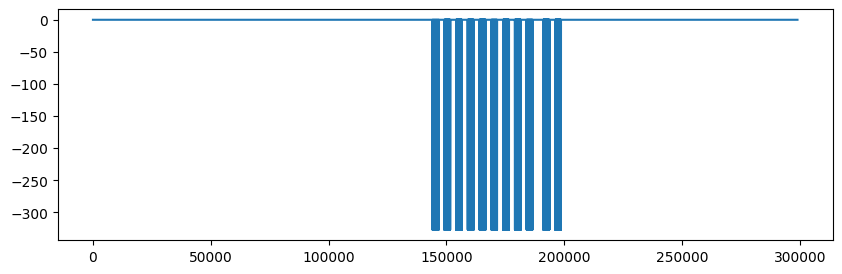

100%|██████████| 2170/2170 [00:13<00:00, 156.04it/s]


In [9]:
#check presence of photic ph data and remove calibration signal
bar=tqdm(total=len(data.datasets))

data_photostim = []
photostim_df=pd.DataFrame(index=range(150), columns=data.description.columns)

cnt=0
for i, sample in enumerate(data.datasets):
    
    bar.update(1)

    sample_clean = remove_calibration_signal(sample.raw.get_data(), 100, 1)

    '''if (sample.raw.get_data().shape[1] != sample_clean.shape[1]):
        print(f'Sample {i} has been cleaned')
        plt.figure(figsize=(10,5))
        plt.suptitle(f'Sample {i} - {sample.description["subject"]} - {sample.description["session"]} - {sample.description["segment"]}')
        plt.subplot(211)
        plt.plot(sample.raw.get_data()[19], label='OG')
        plt.plot(sample_clean[19], label='Cleaned')
        plt.legend()
        plt.subplot(212)
        plt.plot(sample.raw.get_data()[0], label='OG')
        plt.plot(sample_clean[0], label='Cleaned')
        plt.legend()
        plt.show()'''

    if not np.all(sample_clean[19] == 0):

        #discard samples which perfectly match the samples_to_discard
        if sample.description['subject'] in samples_to_discard.keys():
            if sample.description['session'] == samples_to_discard[sample.description['subject']]['session']:        
                if sample.description['segment'] == samples_to_discard[sample.description['subject']]['segment']:
                    print(f"Discarding {sample.description['subject']} - {sample.description['session']} - {sample.description['segment']}")
                    continue

        if sample.description['subject'] == 'aaaaaklv':
            print(f'Sample {i} - {sample.description["subject"]} ')
            plt.figure(figsize=(10,3))
            plt.plot(sample_clean[19])
            plt.show()
        
        data_photostim.append(sample_clean)
        photostim_df.loc[cnt]=data.description.loc[i]
        cnt+=1

bar.close()

photostim_df.dropna(inplace=True)


In [10]:
print('Number of samples with photic stimulation:', len(data_photostim))
print('Length of the photostimulation descriptions: ',len(photostim_df))

# count number of samples with photic stimulation per class
print('Number of samples with photic stimulation per class:')
print(photostim_df['epilepsy'].value_counts())

# count the unique subjects
print('Number of unique patients: ',photostim_df['subject'].nunique())

# count how many samples per subject
print('# Samples per subject:')
print(photostim_df['subject'].value_counts().value_counts())

# count how many are from first or second session
print(photostim_df['session'].value_counts())

Number of samples with photic stimulation: 40
Length of the photostimulation descriptions:  40
Number of samples with photic stimulation per class:
0    27
1    13
Name: epilepsy, dtype: int64
Number of unique patients:  31
# Samples per subject:
1    25
3     3
2     3
Name: subject, dtype: int64
1    26
2     9
3     4
6     1
Name: session, dtype: int64


# Extract photostimulation trials

Length of the photostimulation periods:  40
Length of the windows descriptions:  41
FULL SAMPLE - Start: 250, End: 142408, Midpoint: 71329


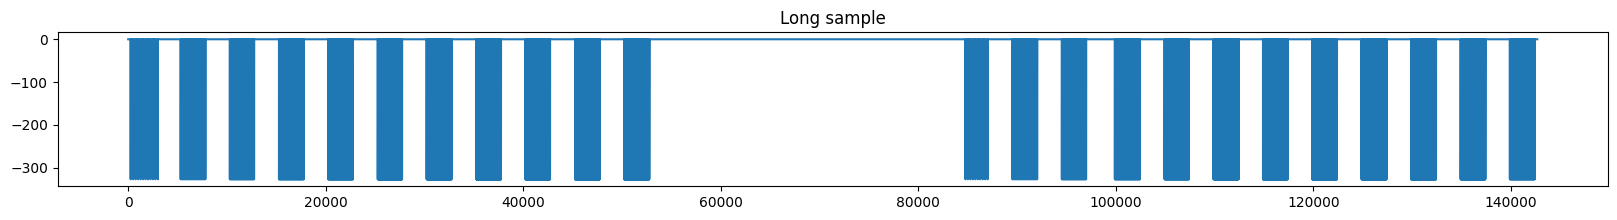

1st part: Start: 0, End: 52498
First part: 52748
Sanity check length: 52748


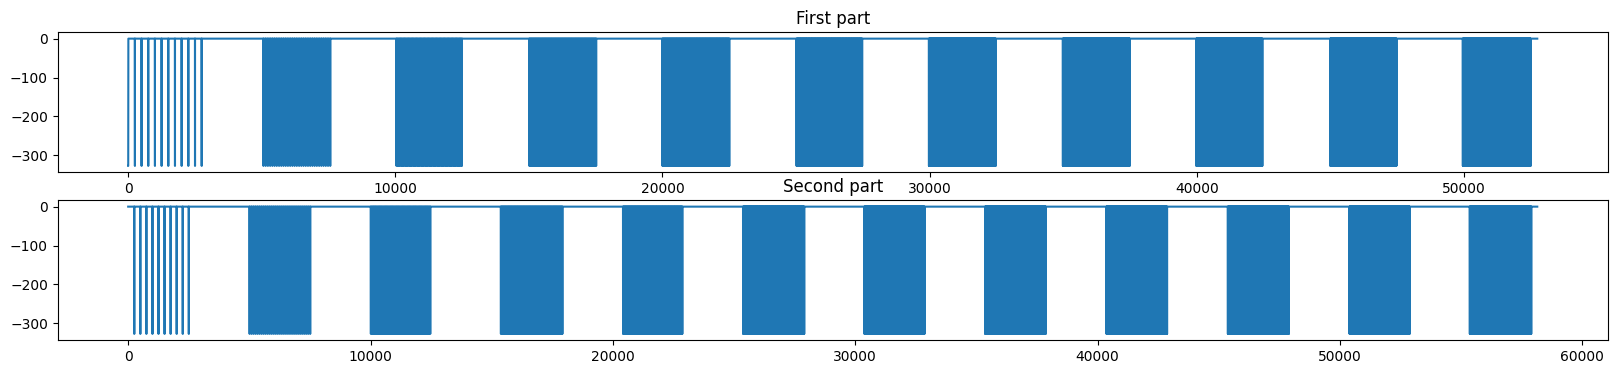

SANITY CHECK
Length of the photostimulation periods:  41
Length of the windows descriptions:  41


In [11]:
data_photostim_montage = []

for i in range(len(data_photostim)):
    temp=data_photostim[i][:19]-np.mean(data_photostim[i][:19], axis=0, keepdims=True)
    temp=np.concatenate((temp, data_photostim[i][19:]), axis=0)
    data_photostim_montage.append(temp)
    
#for each sample in data_photostim, get the first non zero value of the 20th channel and the last non zero value of the 20th channel
#and plot the corresponding segment of the 20th channel

photostim_periods = []
no_photostim_periods=[]

wins_df=pd.DataFrame(index=range(150), columns=data.description.columns)
no_ph_df=pd.DataFrame(index=range(150), columns=data.description.columns)

for i in range(len(data_photostim_montage)):

    for t in range(data_photostim_montage[i].shape[1]): # find the first non-zero value
        if np.abs(data_photostim_montage[i][19, t]) > 1:
            start = t
            break
    for t in range(data_photostim_montage[i].shape[1]-1, 0, -1): # find the last non-zero value
        if np.abs(data_photostim_montage[i][19, t]) > 1:
            end = t
            break

    start-=250 # add 1s before the first non-zero value
    end+=250 # add 1s after the last non-zero value

    temp=data_photostim_montage[i][:, start:end] # get the segment
    
    '''
    print('Length of the segment - sample :',i,' ', (end-start)/250)
    plt.figure(figsize=(10, 2))
    plt.title(f'Subject: {photostim_df.loc[i]['subject']} - Session: {photostim_df.loc[i]['session']} - Segment {photostim_df.loc[i]['segment']} - Epilepsy: {photostim_df.loc[i]['epilepsy']}')
    plt.plot(temp[19,:])
    plt.show()'''

    photostim_periods.append(temp)
    wins_df.loc[i]=photostim_df.loc[i]

    del temp

    temp1=data_photostim_montage[i][:, :start]
    temp2=data_photostim_montage[i][:, end:]
    temp=np.concatenate((temp1, temp2), axis=1)

    no_photostim_periods.append(temp)
    no_ph_df.loc[i]=photostim_df.loc[i]

    del temp1, temp2, temp


#duplicate .iloc[10] since the recording has 2 different photostimulation periods
temp_df=wins_df.copy().iloc[:11]
temp_df2=wins_df.copy().iloc[10:]

wins_df=pd.concat([temp_df, temp_df2], ignore_index=True, axis=0)
wins_df.dropna(inplace=True)

print('Length of the photostimulation periods: ',len(photostim_periods))
print('Length of the windows descriptions: ',len(wins_df))

long_sample=copy(photostim_periods[10])

for t in range(long_sample.shape[1]):
    if np.abs(long_sample[19, t]) > 1:
        start = t
        break
for t in range(long_sample.shape[1]-1, 0, -1):
    if np.abs(long_sample[19, t]) > 1:
        end = t
        break

midpoint = (start+end)//2
first_part = copy(long_sample[:, start:midpoint+250])
second_part = copy(long_sample[:, midpoint-250:end+250])

print(f'FULL SAMPLE - Start: {start}, End: {end}, Midpoint: {midpoint}')

plt.figure(figsize=(20, 2))
plt.plot(long_sample[19,:])
plt.title('Long sample')
plt.show()

for t in range(first_part.shape[1]):
    if np.abs(first_part[19, t]) > 1:
        start = t
        break
for t in range(first_part.shape[1]-1, 0, -1):
    if np.abs(first_part[19, t]) > 1:
        end = t
        break

print(f'1st part: Start: {start}, End: {end}')

end1=end+250

first_part = copy(first_part[:, start:end1])

print('First part:', first_part.shape[1])
print(f'Sanity check length: {(end1-start)}')

for t in range(second_part.shape[1]):
    if np.abs(second_part[19, t]) > 1:
        start = t
        break
for t in range(second_part.shape[1]-1, 0, -1):
    if np.abs(second_part[19, t]) > 1:
        end = t
        break

second_part = copy(second_part[:, start-250:end+250])

plt.figure(figsize=(20, 4))
plt.subplot(2, 1, 1)
plt.plot(first_part[19,:])
plt.title('First part')
plt.subplot(2, 1, 2)
plt.plot(second_part[19,:])
plt.title('Second part')
plt.show()

photostim_periods[10]=first_part
photostim_periods.insert(11, second_part)

print('SANITY CHECK')
print('Length of the photostimulation periods: ',len(photostim_periods))
print('Length of the windows descriptions: ',len(wins_df))

In [23]:
print('Number of samples with photic stimulation:', len(no_photostim_periods))
print('Length of the photostimulation descriptions: ',len(no_ph_df))

#save no_photostim_periods
with open('no_photostim_periods.pkl', 'wb') as f:
    pickle.dump(no_photostim_periods, f)


no_ph_df.dropna(inplace=True)
no_ph_df.to_csv('no_photostim.csv')

Number of samples with photic stimulation: 40
Length of the photostimulation descriptions:  40


/tmp/ipykernel_3799035/1758458705.py:17: RuntimeWarning: divide by zero encountered in log10
  plt.pcolormesh(t, f[f<=flim], 10*np.log10(Sxx[f<=flim,:]), shading='gouraud')


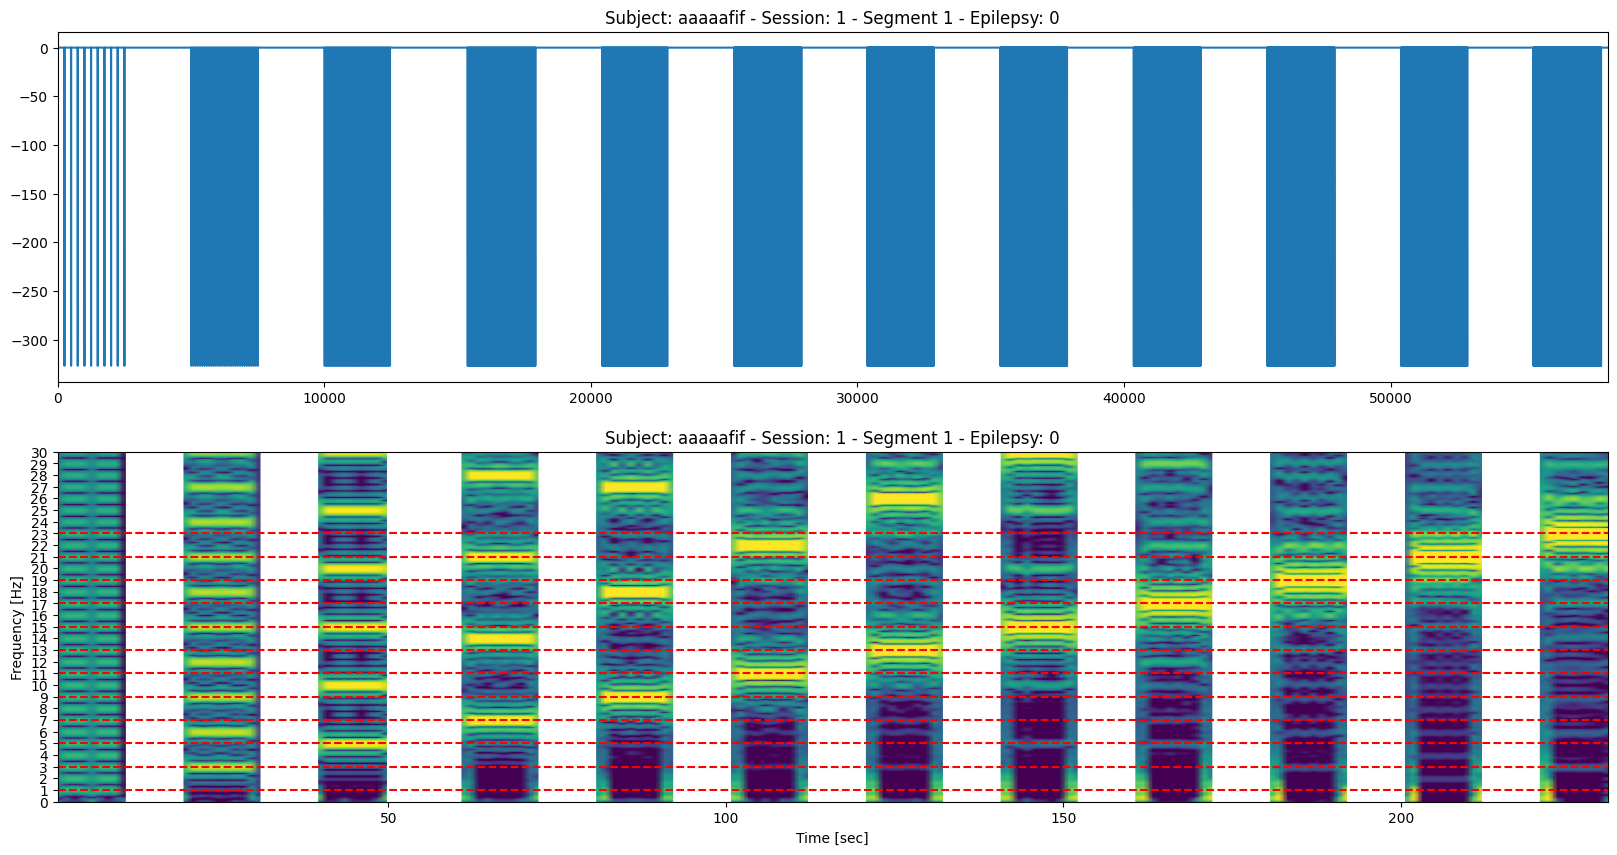

In [14]:
from scipy.signal import spectrogram

i=11

f, t, Sxx = spectrogram(photostim_periods[i][19], fs=250, nperseg=512, noverlap=200, nfft=4096)

flim=30

#plot only freqs up to flim
plt.figure(figsize=(20,10))
plt.subplot(2, 1, 1)
plt.plot(photostim_periods[i][19])
plt.title(f'Subject: {photostim_df.loc[i]['subject']} - Session: {photostim_df.loc[i]['session']} - Segment {photostim_df.loc[i]['segment']} - Epilepsy: {photostim_df.loc[i]['epilepsy']}')
plt.xlim(0, photostim_periods[i].shape[1])

plt.subplot(2, 1, 2)
plt.pcolormesh(t, f[f<=flim], 10*np.log10(Sxx[f<=flim,:]), shading='gouraud')
plt.title(f'Subject: {photostim_df.loc[i]['subject']} - Session: {photostim_df.loc[i]['session']} - Segment {photostim_df.loc[i]['segment']} - Epilepsy: {photostim_df.loc[i]['epilepsy']}')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.yticks(np.arange(0, flim+1, 1))
plt.clim(-5, 30)

#plot horizontal lines at range(1, 21, 2)
for ii in range(1, 25, 2):
    plt.axhline(y=ii, color='r', linestyle='--')
plt.show()

#compute stft of channel 18
f, t, Sxx = spectrogram(photostim_periods[i][18], fs=250, nperseg=512, noverlap=200, nfft=4096)

In [15]:
wins_df

,path,version,year,month,day,subject,session,segment,age,gender,epilepsy
0,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaaanr,1,1,35,M,0
1,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaaawu,1,1,51,F,0
2,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaabdn,1,0,47,F,0
3,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaabhz,1,1,63,F,0
4,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2003,1,1,aaaaabju,1,1,64,F,0
5,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2004,1,1,aaaaaawu,2,0,55,F,0
6,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2004,1,1,aaaaacrz,1,1,57,M,0
7,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2005,1,1,aaaaadkv,1,1,42,F,0
8,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2006,1,1,aaaaaebo,1,0,68,F,1
9,/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/v2....,v2.0.3,2006,1,1,aaaaaelp,1,0,54,M,0


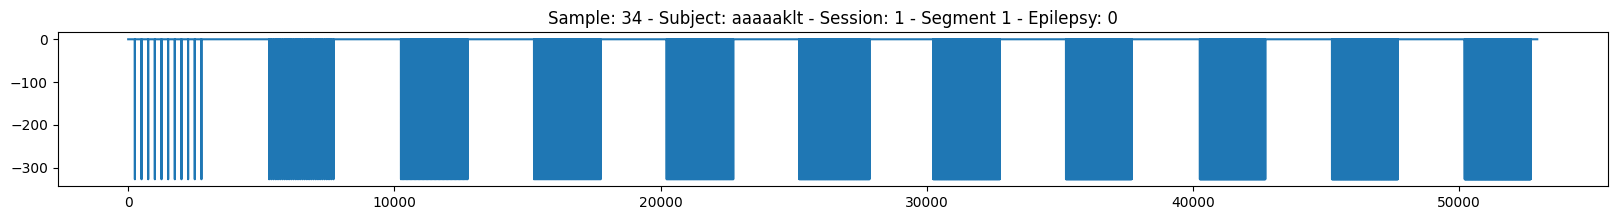

34


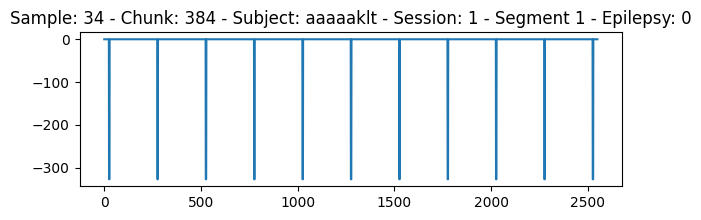

34


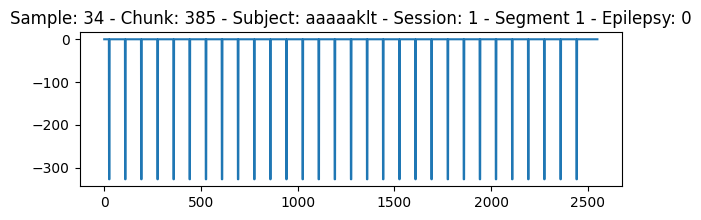

34


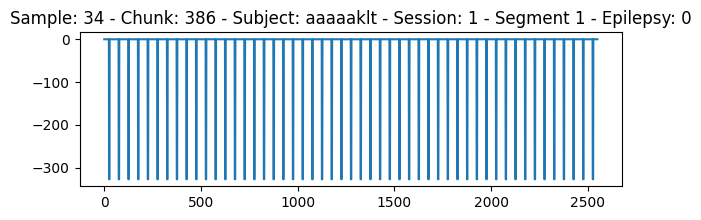

34


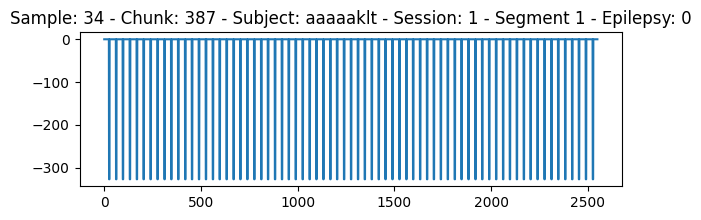

34


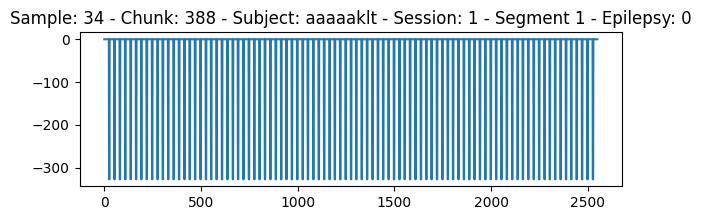

34


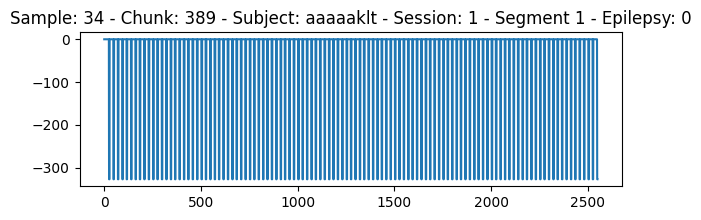

34


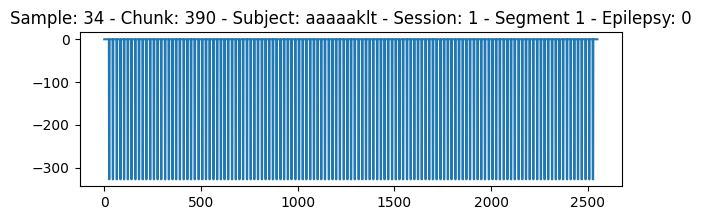

34


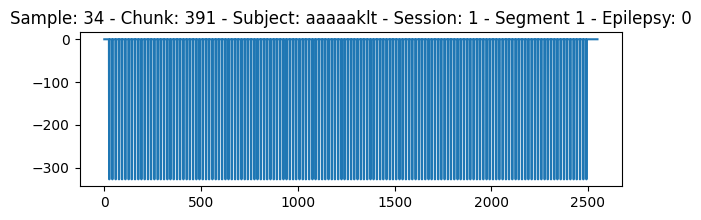

34


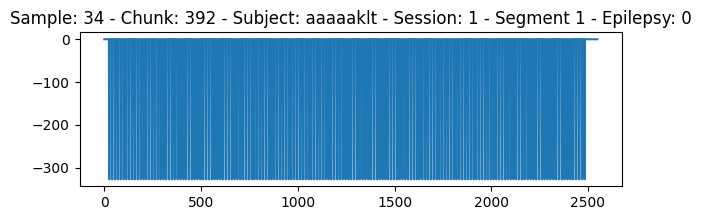

34


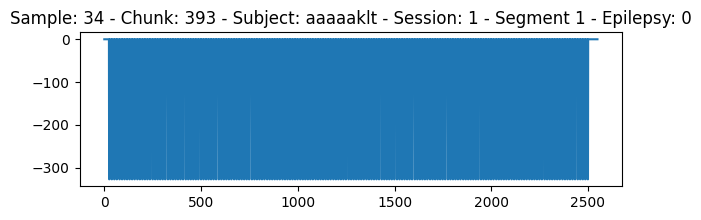

34


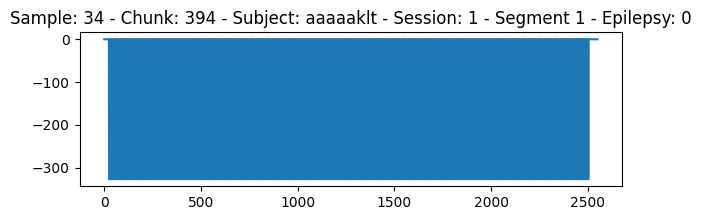

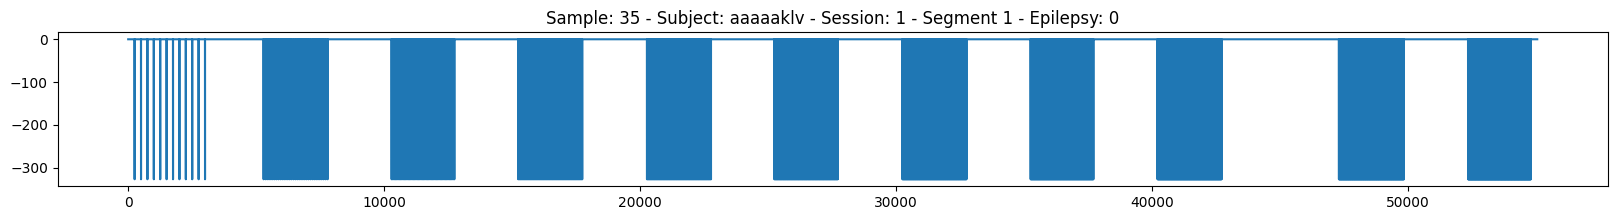

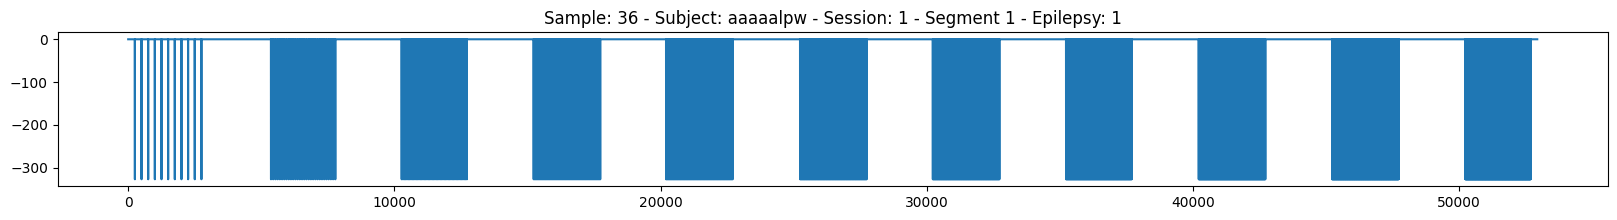

36


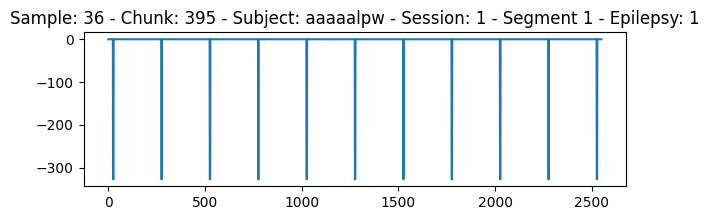

36


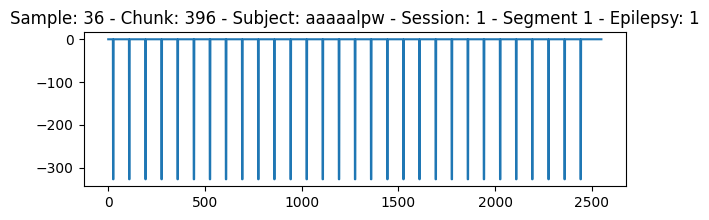

36


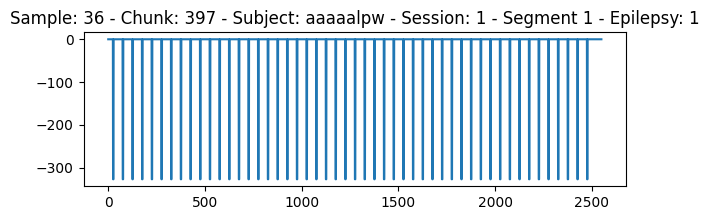

36


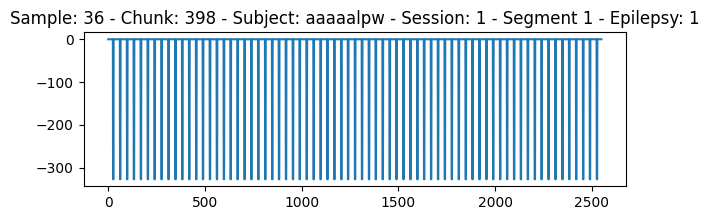

36


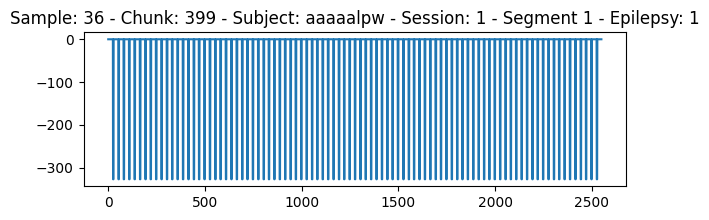

36


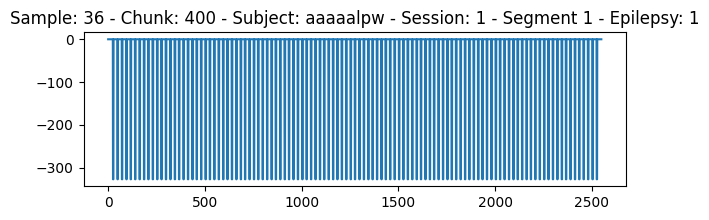

36


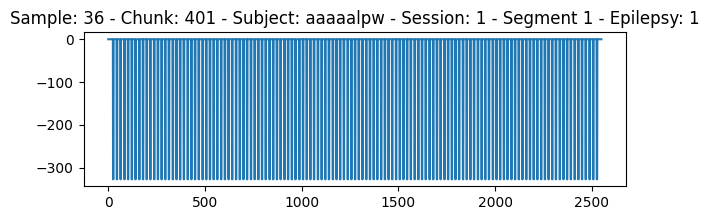

36


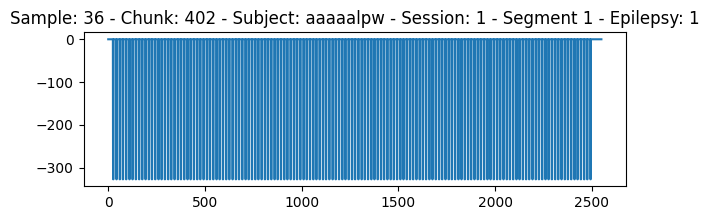

36


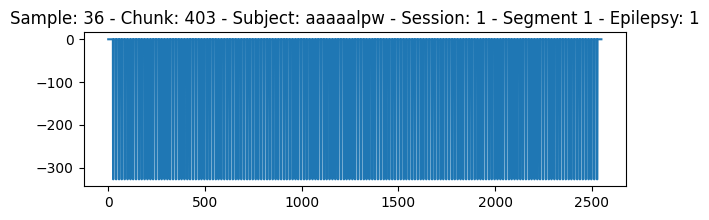

36


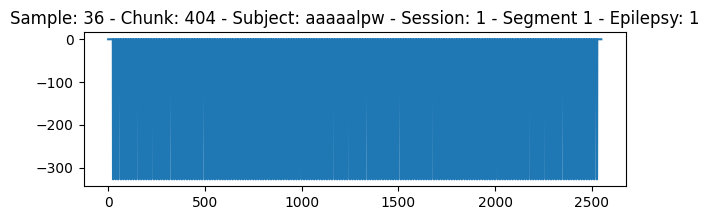

36


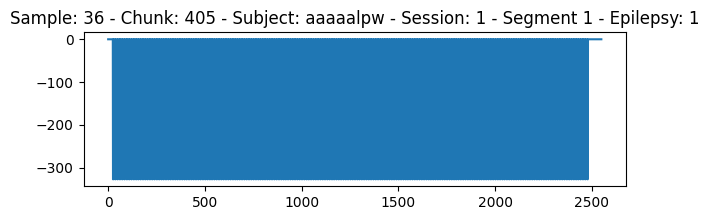

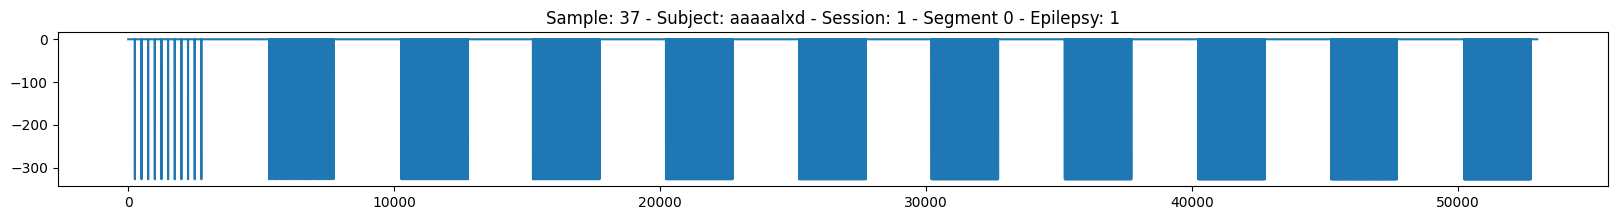

37


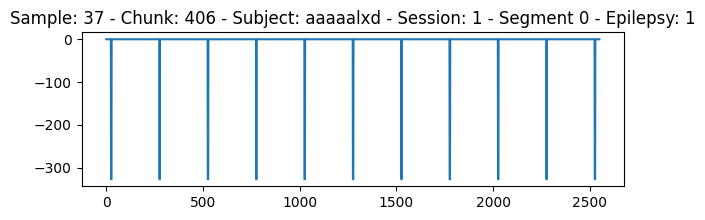

37


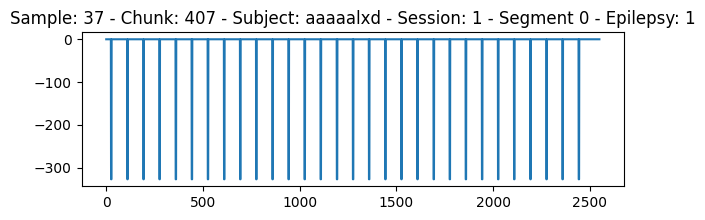

37


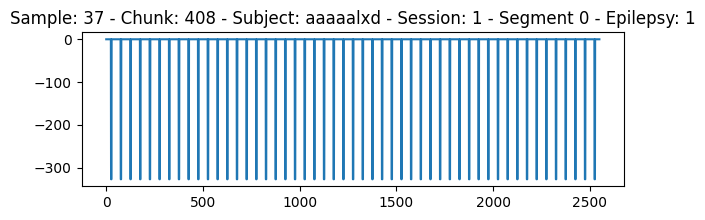

37


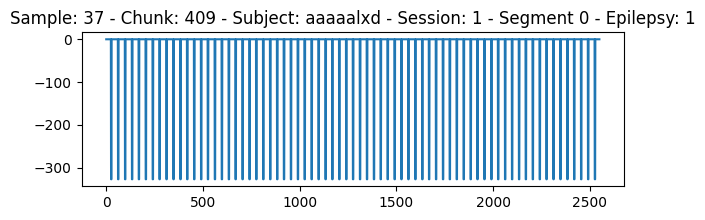

37


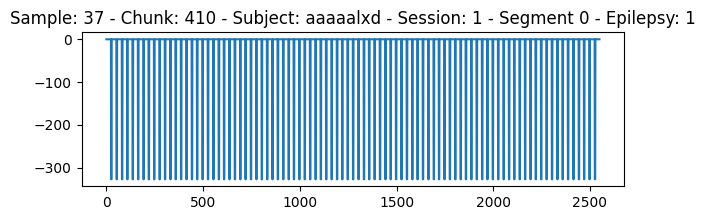

37


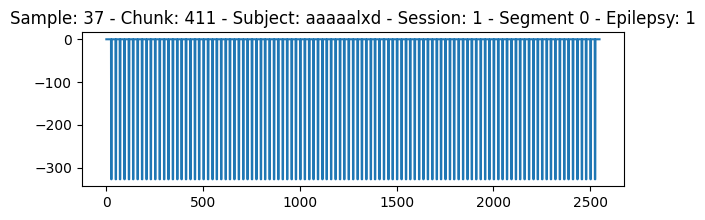

37


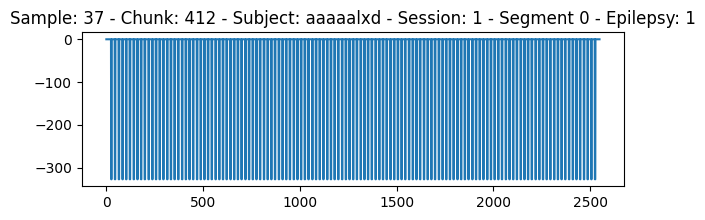

37


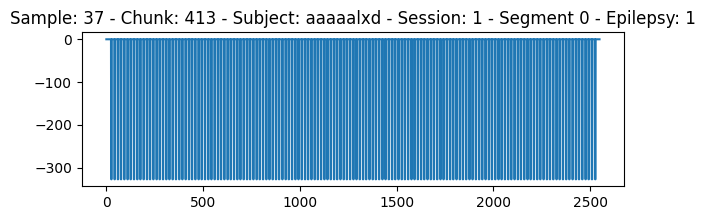

37


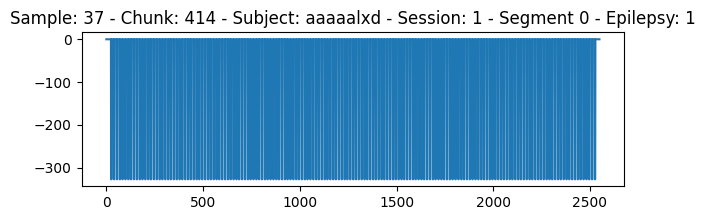

37


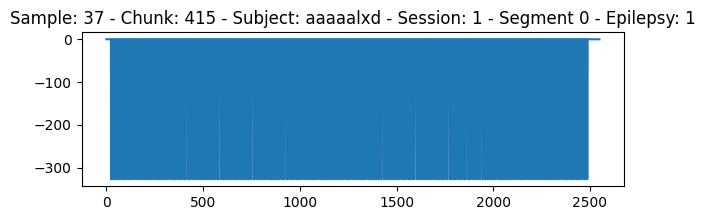

37


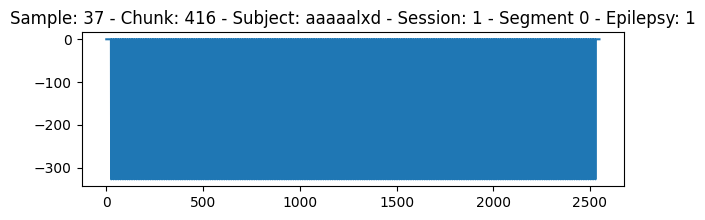

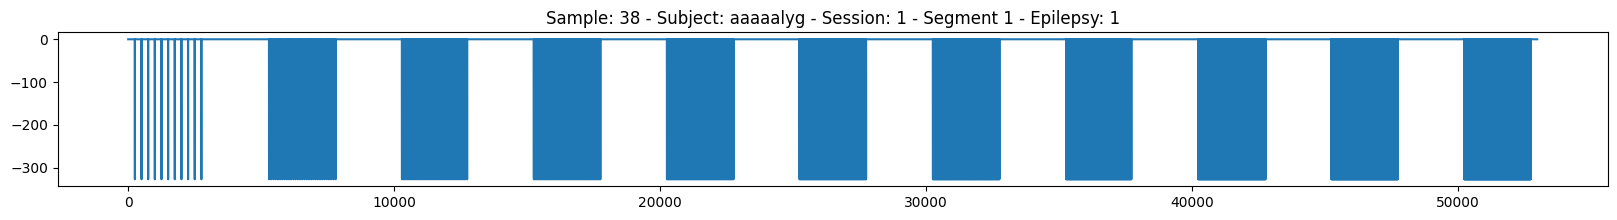

38


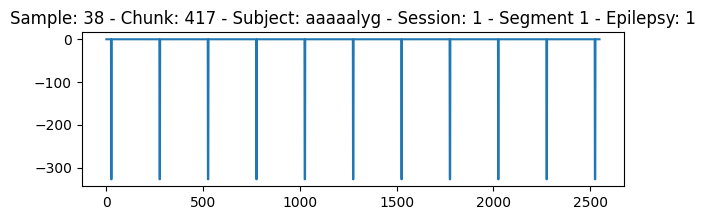

38


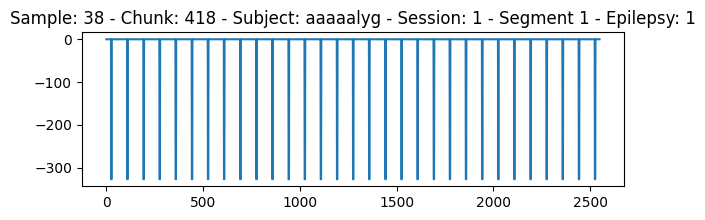

38


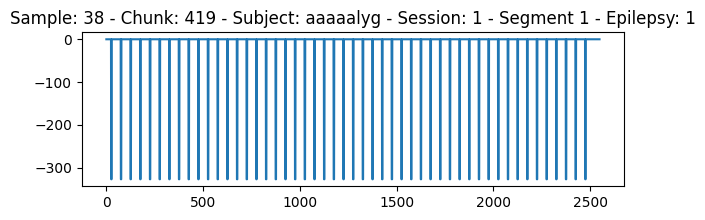

38


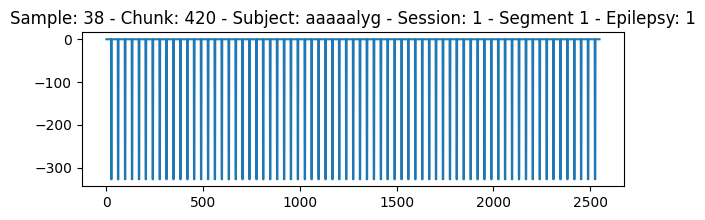

38


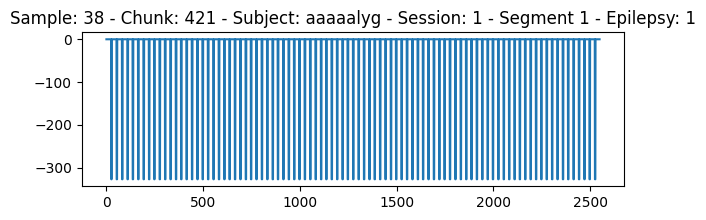

38


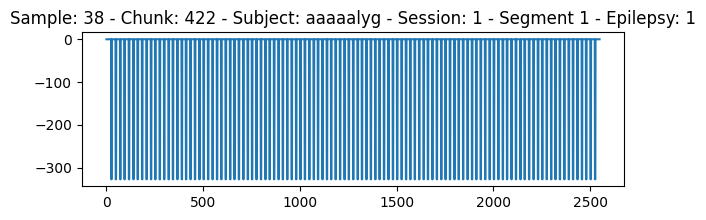

38


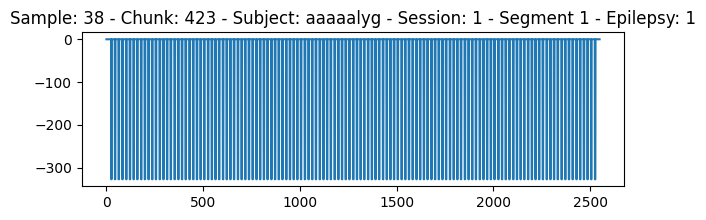

38


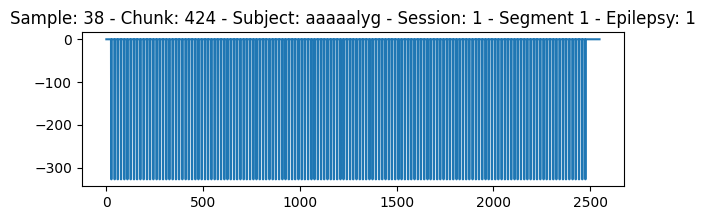

38


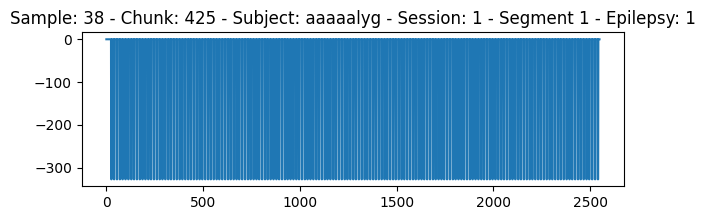

38


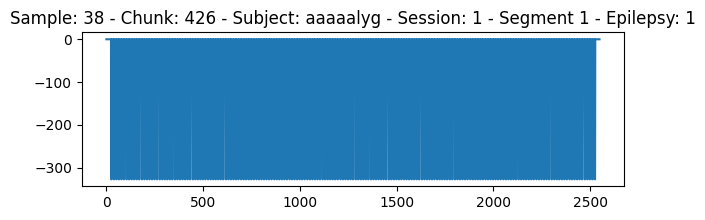

38


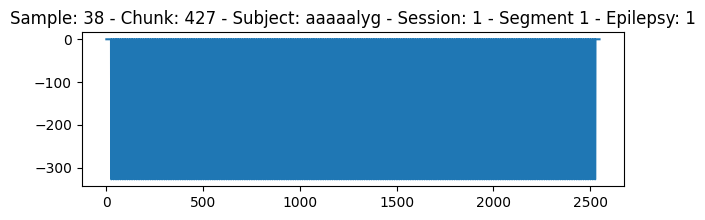

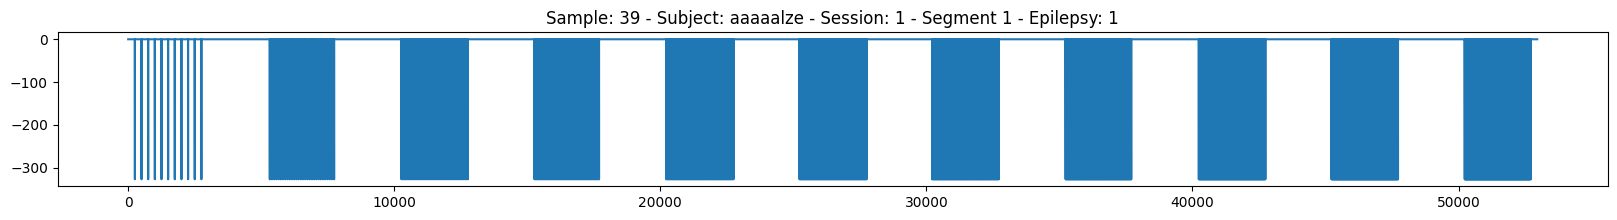

39


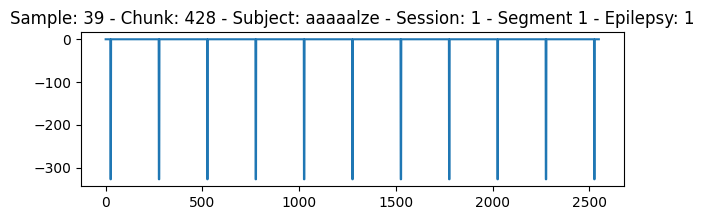

39


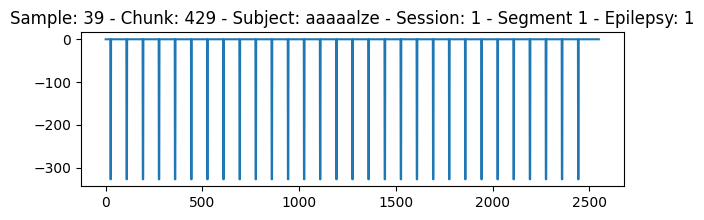

39


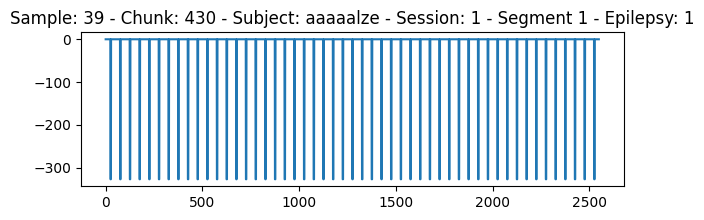

39


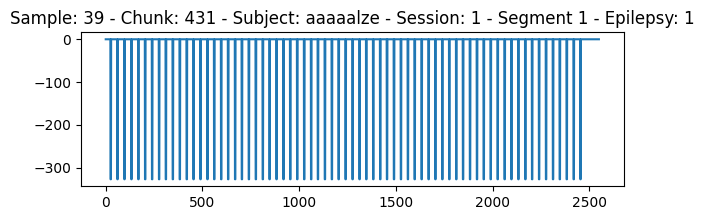

39


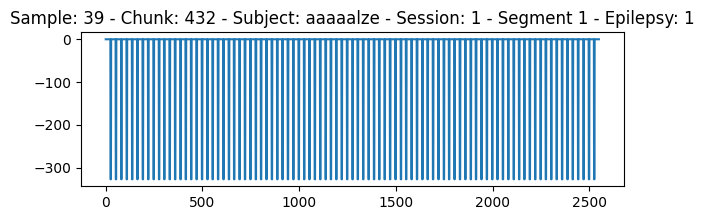

39


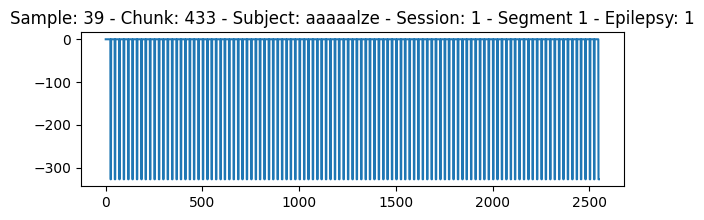

39


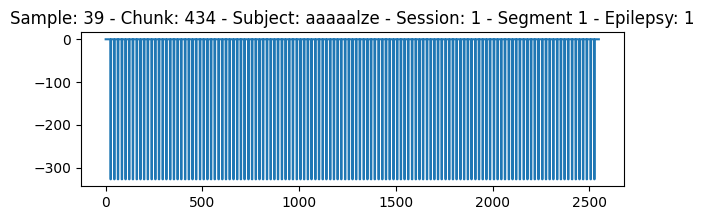

39


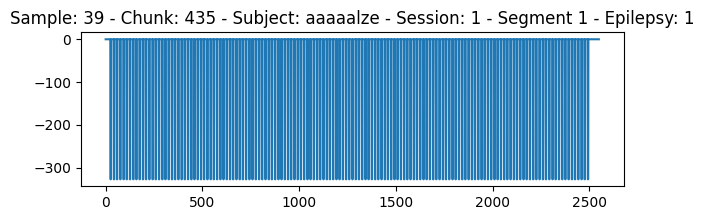

39


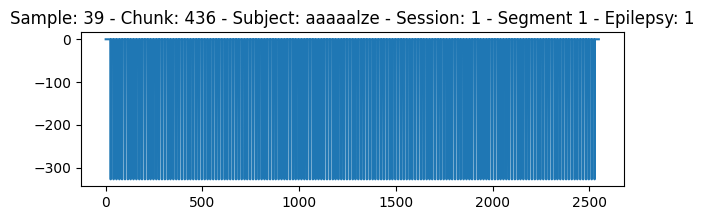

39


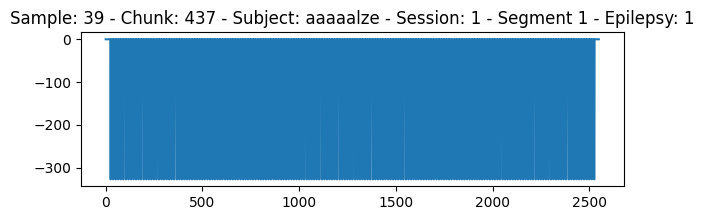

39


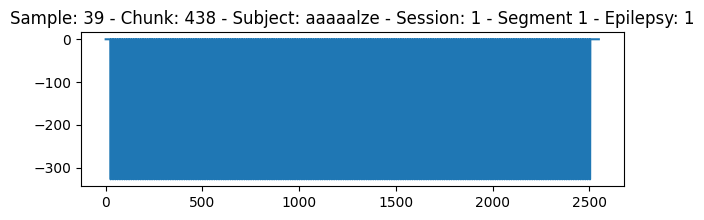

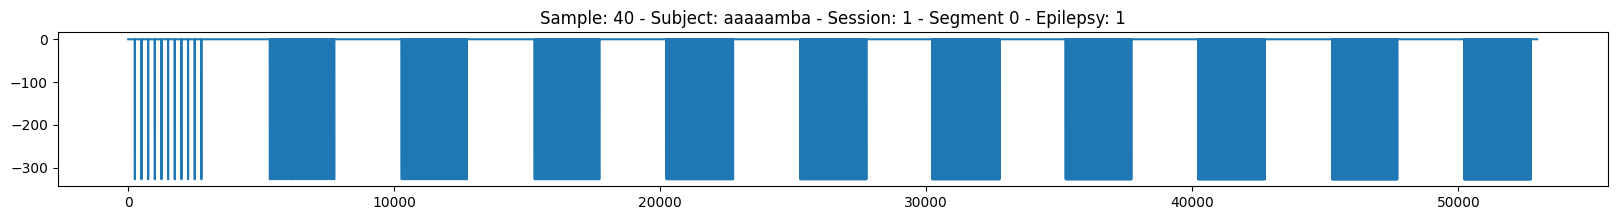

40


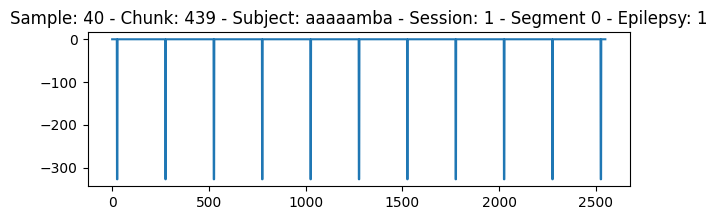

40


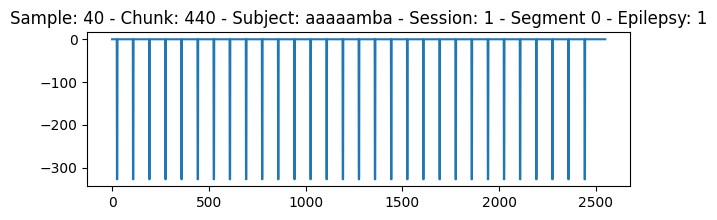

40


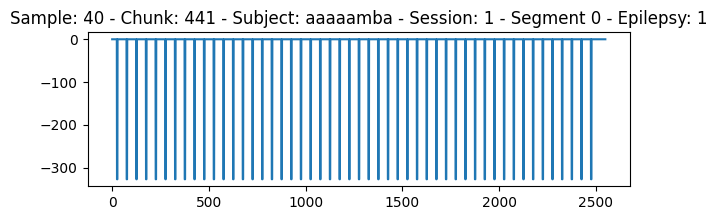

40


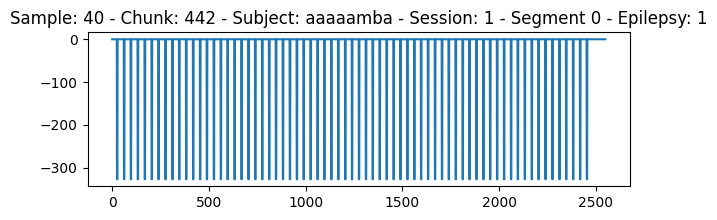

40


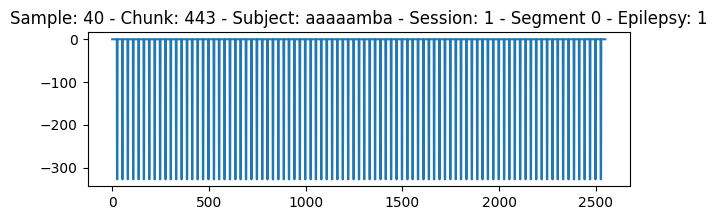

40


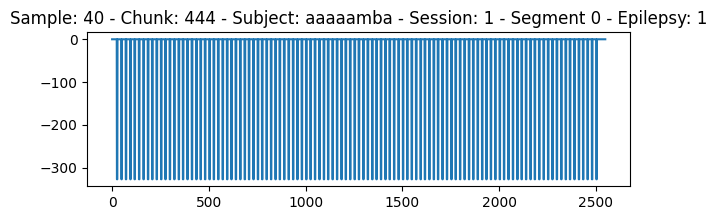

40


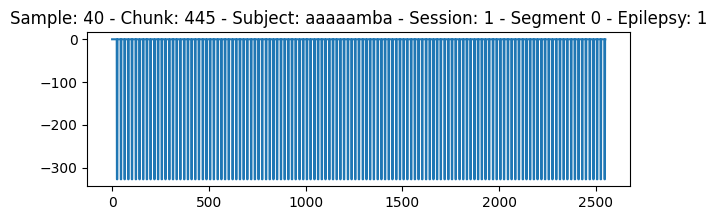

40


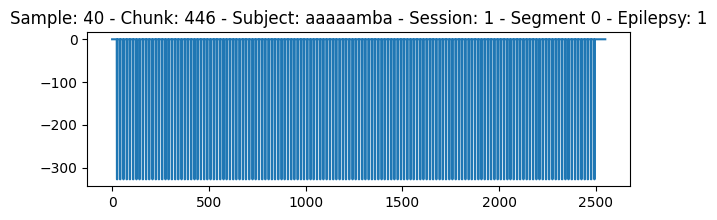

40


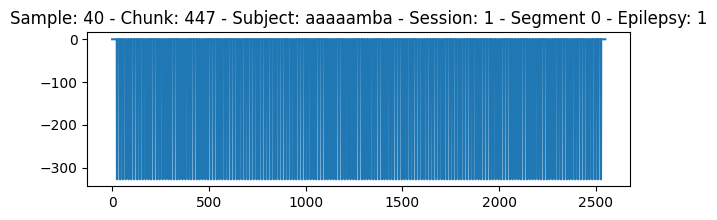

40


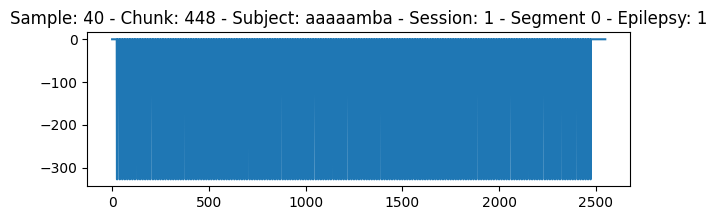

40


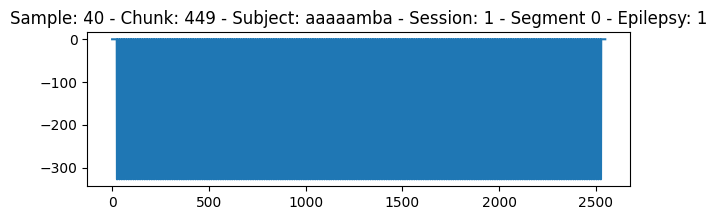

Length of the photostimulation chunks:  450
Length of the chunks descriptions:  470


In [16]:
photostim_chunks= []
chunk_length=19.3
chunk_samples=int(chunk_length*250)

chunks_df=pd.DataFrame(index=range(470), columns=wins_df.columns)
# add a 'frequency; column
chunks_df['frequency']=np.nan
ctr=0

for i in range(len(photostim_periods)):

    if i > 33:
        plt.figure(figsize=(20, 2))
        plt.plot(photostim_periods[i][19])
        plt.title(f'Sample: {i} - Subject: {wins_df.loc[i]["subject"]} - Session: {wins_df.loc[i]["session"]} - Segment {wins_df.loc[i]["segment"]} - Epilepsy: {wins_df.loc[i]["epilepsy"]}')
        plt.show()

    if i==35:
        continue

    for t in range(100, photostim_periods[i].shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        
        if t+chunk_samples <= photostim_periods[i].shape[1]:
            temp=photostim_periods[i][:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=photostim_periods[i][:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 1:
                start = abc - 25
                break

        '''
        for abc in range(temp.shape[1]-1, 0, -1): # find the last non-zero value
            if np.abs(temp[19, abc]) > 1:
                end = abc
                break
        '''

        end = start + 2550        
        temp=copy(temp[:, start:end])

        if i > 33:
            print(i)
            plt.figure(figsize=(7, 2))
            plt.title(f'Sample: {i} - Chunk: {ctr} - Subject: {wins_df.loc[i]["subject"]} - Session: {wins_df.loc[i]["session"]} - Segment {wins_df.loc[i]["segment"]} - Epilepsy: {wins_df.loc[i]["epilepsy"]}')
            plt.plot(temp[19])
            plt.show()

        numpeaks=find_peaks(abs(temp[19]), height=1)[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.
        stim_freq_round=rto(stim_freq)

        photostim_chunks.append(temp)

        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round

        ctr+=1

print('Length of the photostimulation chunks: ',len(photostim_chunks))
print('Length of the chunks descriptions: ',len(chunks_df))

## Hardcode for sample 35 since it had a weird interval

In [ ]:
odd_one=photostim_periods[35]

chunk_length=19.8
chunk_samples=int(chunk_length*250)

ctr=450
i=35

first_part=copy(odd_one[:, :45000])
second_part=copy(odd_one[:, 45000:])

for t in range(200, first_part.shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        if t+chunk_samples <= first_part.shape[1]:
            temp=first_part[:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=first_part[:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 1:
                start = abc - 25
                break
 
        end = start + 2550
        
        temp=copy(temp[:, start:end])

        '''plt.figure(figsize=(7, 2))
        plt.plot(temp[19])
        plt.show()'''

        numpeaks=find_peaks(abs(temp[19]), height=1)[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.
        stim_freq_round=rto(stim_freq)

        photostim_chunks.append(temp)
        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round
        ctr+=1

for t in range(100, second_part.shape[1], chunk_samples): #range(200, photostim_periods[i].shape[1], chunk_samples): WAS WORKING
        if t+chunk_samples <= second_part.shape[1]:
            temp=second_part[:, t:t+chunk_samples]
        else: # if the last chunk is smaller than chunk_samples
            temp=second_part[:, t:]

        if np.all(temp[19] == 0): # if the 20th channel is all zeros, skip
            continue

        for abc in range(temp.shape[1]): # find the first non-zero value
            if np.abs(temp[19, abc]) > 1:
                start = abc - 25
                break
 
        end = start + 2550

        temp=copy(temp[:, start:end])

        '''plt.figure(figsize=(7, 2))
        plt.plot(temp[19])
        plt.show()'''

        numpeaks=find_peaks(abs(temp[19]), height=1)[0].shape[0]
        stim_freq=numpeaks/(temp.shape[1]/250)
        #round the frequency to the nearest odd number: Add 1, Divide by 2, Round, Multiply by 2, Subtract 1.
        stim_freq_round=rto(stim_freq)

        photostim_chunks.append(temp)
        chunks_df.loc[ctr]=wins_df.loc[i]
        chunks_df.loc[ctr, 'frequency']=stim_freq_round
        ctr+=1

chunks_df.dropna(inplace=True)
chunks_df['frequency']=chunks_df['frequency'].astype(int)

print('Length of the photostimulation chunks: ',len(photostim_chunks))
print('Length of the chunks descriptions: ',len(chunks_df))

In [ ]:
print(chunks_df['epilepsy'].value_counts())

#plot histogram of the frequencies
plt.figure(figsize=(7, 4))
plt.hist(chunks_df['frequency'], edgecolor='black', bins=range(1,26,2), align='left')
plt.ylabel('Count')
plt.xlabel('Frequency [Hz]')
plt.title('Stimuli frequency distribution')
plt.xticks(np.arange(1, 24, 2))
plt.show()

In [ ]:
for i, chunk in enumerate(photostim_chunks):
    print(f'Chunk {i} - Length: {chunk.shape[1]} - Frequency: {chunks_df.loc[i]["frequency"]}')


In [21]:
photostim_chunks_array=np.array(photostim_chunks)

np.save('photostim_steps.npy', photostim_chunks_array)
chunks_df.to_csv('photostim_steps.csv', index=False)
